In [ ]:
#loading require python classes and packages
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import os
from math import sqrt
import lightgbm as lgb
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
import xgboost as xg
import shap
from sklearn.metrics import mean_absolute_percentage_error

In [ ]:
#load and display dataset values
dataset = pd.read_csv("Dataset/data.csv")
dataset.fillna(0, inplace = True) #replace missing values with 0
dataset

,Teu,Train_Length,Wagon_Quantity,Train_Weight,Distance_Station,Total_Distance,Departure_Delay,Delay
0,98,5,-11.0,194.0,1448,430,408.0,-22.0
1,2336,10,-8.0,279.0,2330,750,741.0,-9.0
2,840,20,-2.0,293.0,2296,806,811.0,5.0
3,258,20,-5.0,281.0,2342,805,756.0,-9.0
4,135,25,-1.0,215.0,1448,320,259.0,-21.0
...,...,...,...,...,...,...,...,...
2995,1982,940,-4.0,126.0,728,1150,1142.0,-8.0
2996,2051,940,-9.0,170.0,1013,1238,1221.0,-17.0
2997,427,940,-5.0,237.0,1452,1146,1132.0,-14.0
2998,707,940,22.0,130.0,696,1100,1112.0,12.0


In [3]:
#remove features if they are highly correlated
Y = dataset['Delay'].ravel()
dataset.drop(['Delay'], axis = 1,inplace=True)
corr_matrix = dataset.corr().abs() #get correlation
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]#get all columns whose correlation value > 95%
if len(to_drop) > 0:
    dataset.drop(to_drop, axis=1, inplace=True)#drop columns if highlqy correlated
columns = dataset.columns.tolist()
print("Available columns in Dataset : "+str(columns))

Available columns in Dataset : ['Teu', 'Train_Length', 'Wagon_Quantity', 'Train_Weight', 'Distance_Station', 'Total_Distance', 'Departure_Delay']


[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000683 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1571
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 7
[LightGBM] [Info] Start training from score -0.723667

Features with importance values
           Features  Importances
1               Teu     4.040404
0      Train_Length     6.464646
2    Wagon_Quantity    14.343434
3      Train_Weight    16.161616
4  Distance_Station    16.363636
5    Total_Distance    20.808081
6   Departure_Delay    21.818182


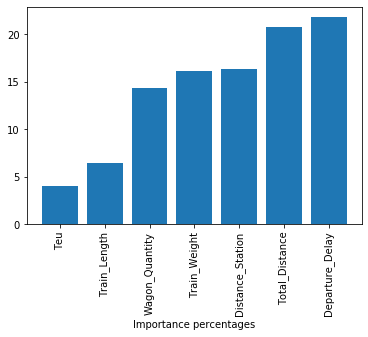

In [5]:
#plot features importance graph using Light GBM
X = dataset.values
clf = lgb.LGBMRegressor(num_leaves=100,learning_rate=0.2,boosting_type='gbdt',n_estimators=5)
clf.fit(X, Y) #train LGBM on X and Y training data
#calculate importance
feature_importances = (clf.feature_importances_ / sum(clf.feature_importances_)) * 100
results = pd.DataFrame({'Features': columns, 'Importances': feature_importances})
results.sort_values(by='Importances', inplace=True)
print()
print("Features with importance values")
print(results)
columns = results['Features'].tolist()
importance = results['Importances'].tolist()
ax = plt.bar(results['Features'], results['Importances'])
plt.xlabel('Importance percentages')
plt.xticks(rotation = 90)
plt.show()


In [6]:
#preprocess dataaset such as normalization and train and test features extraction
Y = Y.reshape(-1, 1)
sc1 = MinMaxScaler(feature_range = (0, 1))
sc2 = MinMaxScaler(feature_range = (0, 1))
X = sc1.fit_transform(X) #normalize features
Y = sc2.fit_transform(Y)
#split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2)
print("Total records found in dataset  = "+str(X.shape[0]))
print("Total features found in dataset = "+str(X.shape[1]))
print("80% dataset for training : "+str(X_train.shape[0]))
print("20% dataset for testing  : "+str(X_test.shape[0]))

Total records found in dataset  = 3000
Total features found in dataset = 7
80% dataset for training : 2400
20% dataset for testing  : 600


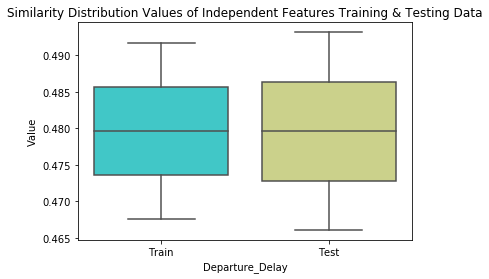

In [8]:
#plot train and test similarity graph using meand and median from departure column
temp = []
temp.append(["Train", np.median(X_train[:,6])])
temp.append(["Test", np.median(X_test[:,6])])
temp.append(["Train", np.mean(X_train[:,6])])
temp.append(["Test", np.mean(X_test[:,6])])
temp = pd.DataFrame(temp, columns = ['Departure_Delay', 'Value'])
sns.boxplot(x='Departure_Delay',y='Value',data=temp,palette='rainbow')
plt.title("Similarity Distribution Values of Independent Features Training & Testing Data")
plt.show()

In [19]:
#now define global variables for mae, mape, rmse and r2
mae = []
rmse = []
mape = []
rsquare = []

In [20]:
#function to calculate MSE and other metrics
def calculateMetrics(algorithm, predict, test_labels):
    predict = predict.reshape(-1, 1)
    mape_value = mean_absolute_percentage_error(test_labels, predict)   
    predict = sc2.inverse_transform(predict)
    test_label = sc2.inverse_transform(test_labels)
    predict = predict.ravel()
    test_label = test_label.ravel()
    rvalue = r2_score(test_label, predict)
    mse_value = mean_squared_error(test_label, predict)
    rmse_value = sqrt(mse_value)
    mae_value = mean_absolute_error(test_label, predict)
    mae.append(mae_value)
    rmse.append(rmse_value)
    mape.append(mape_value)
    rsquare.append(rvalue)
    print()
    print(algorithm+" MAE  : "+str(mae_value))
    print(algorithm+" RMSE : "+str(rmse_value))
    print(algorithm+" MAPE  : "+str(mape_value))
    print(algorithm+" R2  : "+str(rvalue))
    plt.plot(test_label, color = 'red', label = 'Original Delay')
    plt.plot(predict, color = 'green', label = 'Predicted Delay')
    plt.title(algorithm+' Freight Train Delay Prediction')
    plt.xlabel('Test Data')
    plt.ylabel('Predicted Freight Train Delay')
    plt.legend()
    plt.show()

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().


[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000423 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1514
[LightGBM] [Info] Number of data points in the train set: 2400, number of used features: 7
[LightGBM] [Info] Start training from score 0.117785

Light GBM MAE  : 5.139603876393374
Light GBM RMSE : 7.3992927802543695
Light GBM MAPE  : 0.13382593322017697
Light GBM R2  : 0.8947926171435188


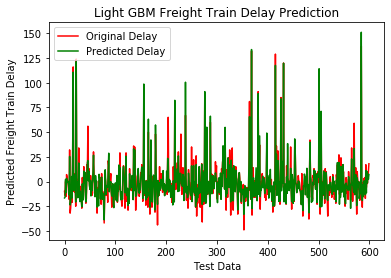

In [21]:
#train Light GBM algortihm on training data and test on testing data
lgb_rg = lgb.LGBMRegressor()
lgb_rg.fit(X_train, y_train.ravel())#train the model
predict = lgb_rg.predict(X_test)#perform prediction on test data
calculateMetrics("Light GBM", predict, y_test)#calculate metrics using original and predicted labels


Linear Regression MAE  : 9.693330888045866
Linear Regression RMSE : 12.667841616871963
Linear Regression MAPE  : 0.25345058089174505
Linear Regression R2  : 0.6916307655138794


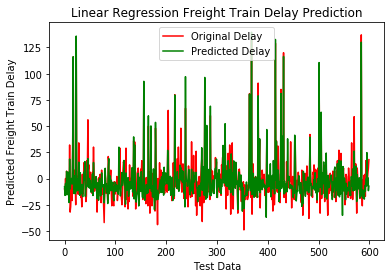

In [22]:
#train Linear Regression algortihm on training data and test on testing data
lr = LinearRegression(fit_intercept=False, copy_X=False)
lr.fit(X_train, y_train.ravel())#train the model
predict = lr.predict(X_test)#perform prediction on test data
calculateMetrics("Linear Regression", predict, y_test)#calculate metrics using original and predicted labels

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().



Random Forest MAE  : 7.118916666666667
Random Forest RMSE : 9.807943506838386
Random Forest MAPE  : 0.18396082938523373
Random Forest R2  : 0.8151490425798404


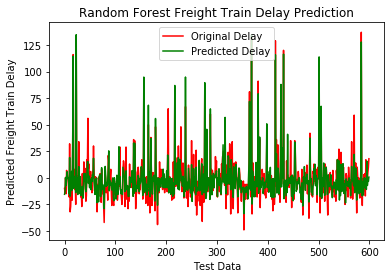

In [23]:
#train Random Forest algortihm on training data and test on testing data
rf = RandomForestRegressor()
rf.fit(X_train, y_train.ravel())#train the model
predict = rf.predict(X_test)#perform prediction on test data
calculateMetrics("Random Forest", predict, y_test)#calculate metrics using original and predicted labels


KNN MAE  : 10.256111111111114
KNN RMSE : 14.055386472412948
KNN MAPE  : 0.2545302246028417
KNN R2  : 0.6203779970661356


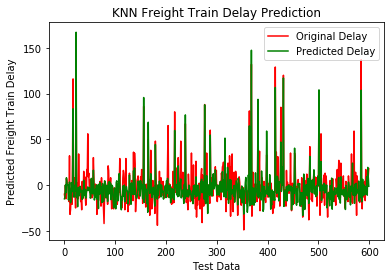

In [24]:
#train KNN algortihm on training data and test on testing data
knn = KNeighborsRegressor(n_neighbors=3)
knn.fit(X_train, y_train.ravel())#train the model
predict = knn.predict(X_test)#perform prediction on test data
calculateMetrics("KNN", predict, y_test)#calculate metrics using original and predicted labels


Extension XGBoost MAE  : 4.865689219682633
Extension XGBoost RMSE : 6.828325684326598
Extension XGBoost MAPE  : 0.12226352326118042
Extension XGBoost R2  : 0.9104028393272756


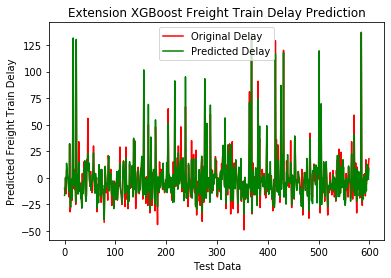

In [25]:
#train extension XGBoost algortihm on training data and test on testing data
xgboost = xg.XGBRegressor()
xgboost.fit(X_train, y_train.ravel())#train the model
predict = xgboost.predict(X_test)#perform prediction on test data
calculateMetrics("Extension XGBoost", predict, y_test)#calculate metrics using original and predicted labels

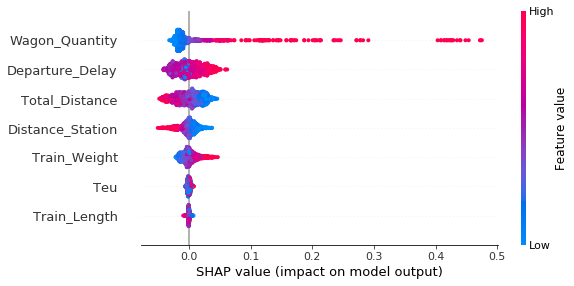

In [26]:
#using shapely we can interpret XGBOOST prediction by checking features importance which help more in getting high
#r2 value
explainer = shap.TreeExplainer(lgb_rg)
shap_values = explainer.shap_values(X_train) #explainer will set on training data
shap.summary_plot(shap_values, X_train, feature_names=columns)#now explain features importance using plot

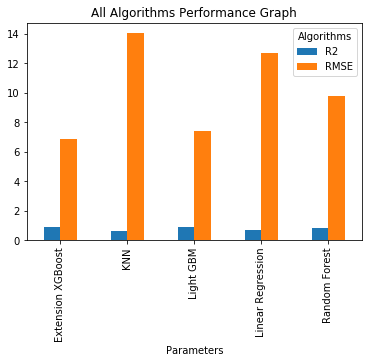

In [28]:
#plot all algorithm performance
df = pd.DataFrame([['Light GBM','R2',rsquare[0]],['Light GBM','RMSE',rmse[0]],
                   ['Linear Regression','R2',rsquare[1]],['Linear Regression','RMSE',rmse[1]],
                   ['Random Forest','R2',rsquare[2]],['Random Forest','RMSE',rmse[2]],
                   ['KNN','R2',rsquare[3]],['KNN','RMSE',rmse[3]],
                   ['Extension XGBoost','R2',rsquare[4]],['Extension XGBoost','RMSE',rmse[4]],
                  ],columns=['Parameters','Algorithms','Value'])
df.pivot("Parameters", "Algorithms", "Value").plot(kind='bar')
plt.title("All Algorithms Performance Graph")
plt.show()

In [29]:
#showing all algorithms with scenario A and B performance values
columns = ["Algorithm Name","R2", "MAE", "RMSE", "MAPE"]
values = []
algorithm_names = ["Light GBM", "Linear Regression", "Random Forest", "KNN","Extension XGBoost"]
for i in range(len(algorithm_names)):
    values.append([algorithm_names[i], rsquare[i], mape[i], mae[i], rmse[i]])
    
temp = pd.DataFrame(values,columns=columns)
temp

,Algorithm Name,R2,MAE,RMSE,MAPE
0,Light GBM,0.894793,0.133826,5.139604,7.399293
1,Linear Regression,0.691631,0.253451,9.693331,12.667842
2,Random Forest,0.815149,0.183961,7.118917,9.807944
3,KNN,0.620378,0.254530,10.256111,14.055386
4,Extension XGBoost,0.910403,0.122264,4.865689,6.828326


In [30]:
#reading test data from test file and then predicting traffic volume
dataset = pd.read_csv("Dataset/testData.csv")
dataset.fillna(0, inplace = True) #remove missing values
temp = dataset.values
testData = dataset.values
#normalizing test data
testData = sc1.transform(testData)
#perform prediction on test
predict = xgboost.predict(testData)
#reshaping and denormalize predicted output
predict = predict.reshape(-1, 1)
predict = sc2.inverse_transform(predict)
for i in range(len(predict)):#now loop each test data and then predict traffic volume
    print("Test Data = "+str(temp[i]))
    print("Predicted Delay ====> "+str(predict[i,0]))
    print()

Test Data = [1500.  510.    4.  182.  925.  805.  816.]
Predicted Delay ====> 10.05116

Test Data = [ 399.  700.   -5.  392. 2475. 1025. 1027.]
Predicted Delay ====> 2.9311402

Test Data = [1133.  740.   -3.  131.  647. 1025. 1048.]
Predicted Delay ====> 20.413258

Test Data = [742. 740.  -1. 108. 406. 910. 927.]
Predicted Delay ====> 11.702452

Test Data = [1104.  758.   18.  143.  862. 1115. 1139.]
Predicted Delay ====> 24.17175

Test Data = [1033.  840.   54.  243. 1671. 1445. 1537.]
Predicted Delay ====> 52.51954

Test Data = [ 835.  935.    9.  335. 2384. 1310. 1319.]
Predicted Delay ====> 9.217901

